# 02 · Entrenar el score y samplear (VP + Euler–Maruyama)

Segundo notebook: cerramos por primera vez el ciclo completo **`forward → score → sampleo`** para
**una celda** de la matriz de ablación. Fijamos la SDE forward en **VP** (Eje 1) y el sampler reverso
en **Euler–Maruyama** (Eje 2), el baseline "puro estocástico".

Pasos:

1. Entrenar la red de score $s_\theta(x,t)\approx\nabla_x\log p_t(x)$ por *denoising score matching*
   (`diffusion.training.train`) — unos minutos en CPU.
2. Ver el **campo de score aprendido** como quiver sobre el plano.
3. Integrar la **SDE reversa** con Euler–Maruyama (`diffusion.samplers.make_sampler`) y comparar las
   muestras generadas contra $p_\text{data}$.

Nada de esto reentrena entre samplers: el notebook `03` reusará esta misma red para los otros
samplers (Eje 2). Acá entrenamos **inline** (sin checkpoints en disco), así el notebook es
autocontenido.

In [1]:
# --- Setup: bootstrap de sys.path + imports + defaults de ploteo ---
import sys
import pathlib
import time

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.data_generation import make_distribution
from diffusion.sde import make_sde
from diffusion.training import TrainConfig, train
from diffusion.samplers import make_sampler, available_samplers

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("paquete en:", _root)
print("samplers disponibles:", available_samplers())

paquete en: c:\Users\bravo\Facultad\Calculo_Estocastico\tp-final\diffusion-models
samplers disponibles: ['euler', 'heun', 'pc', 'pf_ode']


## Entrenar la red de score sobre la VP-SDE

Misma mezcla de 8 gaussianas del notebook `01` (distribución real, `seed=1`). La red es la
**variable de control**: usamos los defaults de `ScoreMLP` (embedding sinusoidal de $t$ + bloques
residuales, determinística) y no los tocamos entre celdas. Los hiperparámetros de optimización son
los del config `config/vp_mixture.yaml`.

In [2]:
dist = make_distribution("mixture", dim=2, n_components=4, standardize=True, seed=1)
sde = make_sde("vp")

cfg = TrainConfig(
    epochs=500,
    batch_size=256,
    n_samples=4000,
    lr=2e-3,
    t_eps=1e-3,
    grad_clip=1.0,
    seed=SEED,
    log_every=50,
)

t0 = time.time()
result = train(sde, dist, cfg)      # instancia una ScoreMLP nueva y la entrena por DSM
result.net.eval()                   # el sampler la consume como función pura, en eval
print(f"entrenamiento: {time.time() - t0:.1f}s  "
      f"pérdida {result.history[0]:.4f} -> {result.history[-1]:.4f}")

[vp] época 1/500  pérdida=0.711451
[vp] época 51/500  pérdida=0.298350
[vp] época 101/500  pérdida=0.264582
[vp] época 151/500  pérdida=0.187431


KeyboardInterrupt: 

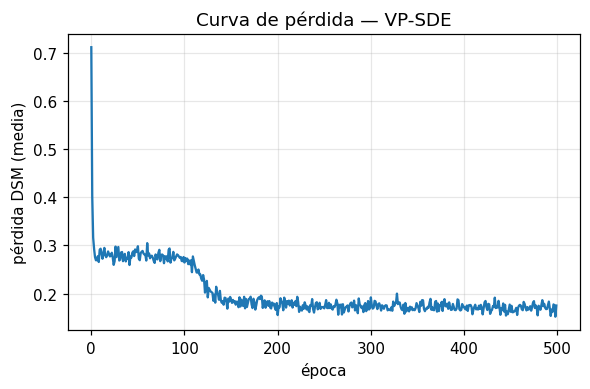

In [19]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(result.history, lw=1.5)
ax.set_xlabel("época")
ax.set_ylabel("pérdida DSM (media)")
ax.set_title("Curva de pérdida — VP-SDE")
plt.show()

## El campo de score aprendido

$s_\theta(x,t)$ es un campo vectorial que apunta hacia zonas de mayor densidad de $p_t$. A **$t$
chico** debería apuntar hacia los 8 modos de la mezcla (dato casi limpio); a **$t$ grande** el campo
se aplana hacia el origen (la densidad ya es casi el prior $\mathcal N(0,I)$).

Las flechas se **normalizan** para ver la dirección (la magnitud del score crece como $1/\text{std}$
cuando $t\to0$); el color codifica la magnitud real.

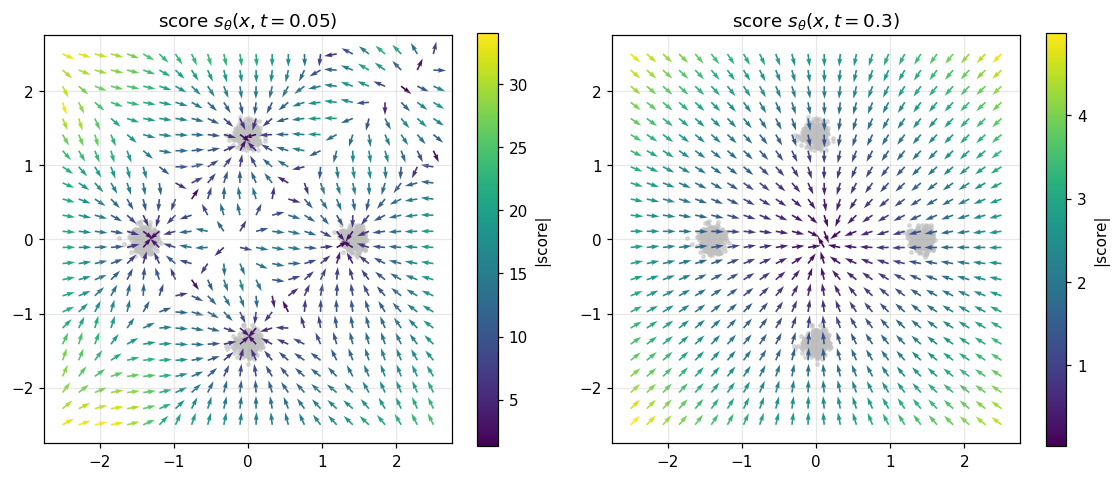

In [20]:
def score_field(net, sde, t_val, lim=2.5, n=24):
    xs = np.linspace(-lim, lim, n)
    gx, gy = np.meshgrid(xs, xs)
    pts = np.stack([gx.ravel(), gy.ravel()], axis=1).astype(np.float32)
    x = torch.from_numpy(pts)
    t = torch.full((x.shape[0],), float(t_val))
    with torch.no_grad():
        s = net(x, t).numpy()
    return gx, gy, s

t_vals = [0.05, 0.3]
fig, axes = plt.subplots(1, len(t_vals), figsize=(5.2 * len(t_vals), 5))
xd = dist.sample(1500)
for ax, tv in zip(axes, t_vals):
    gx, gy, s = score_field(result.net, sde, tv)
    mag = np.linalg.norm(s, axis=1)
    u = s[:, 0] / (mag + 1e-8)
    v = s[:, 1] / (mag + 1e-8)
    ax.scatter(xd[:, 0], xd[:, 1], c="0.75", s=5, alpha=0.5, zorder=0)
    q = ax.quiver(gx.ravel(), gy.ravel(), u, v, mag, cmap="viridis",
                  scale=32, width=0.004, zorder=1)
    ax.set_aspect("equal")
    ax.set_title(f"score $s_\\theta(x, t={tv})$")
    fig.colorbar(q, ax=ax, shrink=0.8, label="|score|")
fig.tight_layout()
plt.show()

## Sampleo reverso con Euler–Maruyama

Con el score fijo, integramos la SDE reversa de Anderson
$dx = [f - g^2 s_\theta]\,dt + g\,d\bar W$ hacia atrás en el tiempo (de $T$ a $t_\epsilon$).
Euler–Maruyama es la discretización estocástica directa: el baseline del Eje 2.

Arrancamos del prior $p_T=\mathcal N(0,I)$ y comparamos la nube generada $x_0$ contra los datos.

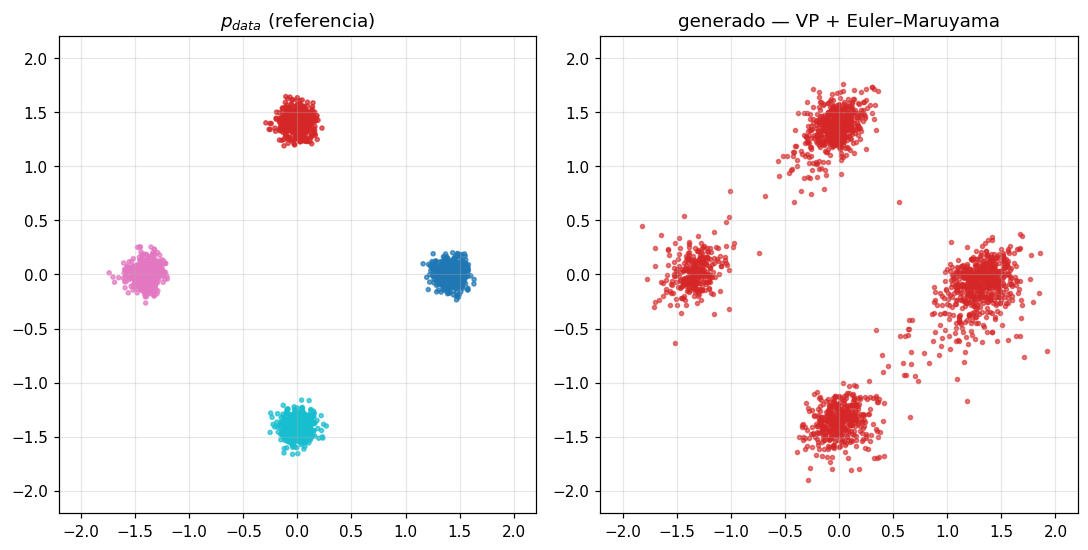

data  mean/std: [-0. -0.] [1. 1.]
gen   mean/std: [0.211 0.052] [0.908 0.985]


In [21]:
sampler = make_sampler("euler", sde, result.net, n_steps=500, t_eps=cfg.t_eps)

gen = torch.Generator().manual_seed(SEED)
N = 2000
x0_gen = sampler.sample(N, generator=gen).numpy()
x0_data = dist.sample(N)

lim = 1.15 * float(np.abs(np.concatenate([x0_gen, x0_data])).max())
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(x0_data[:, 0], x0_data[:, 1], c=dist.color_, cmap="tab10", s=7, alpha=0.7)
axes[0].set_title("$p_{data}$ (referencia)")
axes[1].scatter(x0_gen[:, 0], x0_gen[:, 1], c="C3", s=7, alpha=0.6)
axes[1].set_title("generado — VP + Euler–Maruyama")
for ax in axes:
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print("data  mean/std:", np.round(x0_data.mean(0), 3), np.round(x0_data.std(0), 3))
print("gen   mean/std:", np.round(x0_gen.mean(0), 3), np.round(x0_gen.std(0), 3))

## Trayectorias del proceso reverso

`sample(..., return_trajectory=True)` devuelve todos los estados intermedios (shape
`(n_steps+1, N, 2)`). Graficamos unas pocas partículas desde el prior (ruido, en el borde) hasta
$x_0$ (colapsando a los modos), sobre la nube de datos.

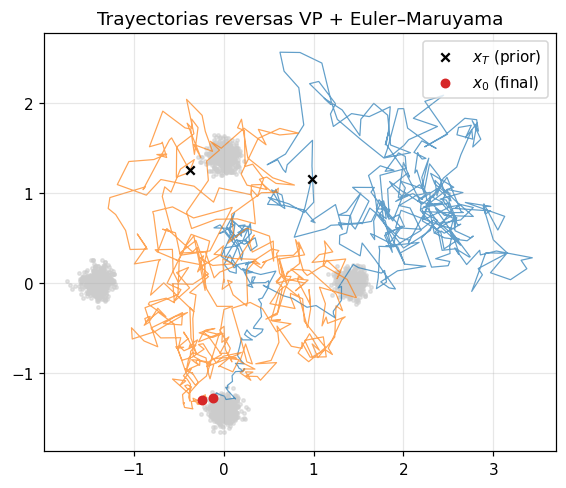

In [28]:
gen = torch.Generator()
n_traj = 2
_, traj = sampler.sample(n_traj, generator=gen, return_trajectory=True)
traj = traj.numpy()   # (n_steps+1, n_traj, 2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x0_data[:, 0], x0_data[:, 1], c="0.8", s=5, alpha=0.5, zorder=0)
for k in range(n_traj):
    ax.plot(traj[:, k, 0], traj[:, k, 1], lw=0.8, alpha=0.7, zorder=1)
ax.scatter(traj[0, :, 0], traj[0, :, 1], c="k", s=30, marker="x", label="$x_T$ (prior)", zorder=2)
ax.scatter(traj[-1, :, 0], traj[-1, :, 1], c="C3", s=30, label="$x_0$ (final)", zorder=2)
ax.set_aspect("equal"); ax.legend(loc="upper right")
ax.set_title("Trayectorias reversas VP + Euler–Maruyama")
plt.show()

## Cierre

- La curva de pérdida baja y se estabiliza: la red aprendió un score utilizable.
- El campo de score apunta a los modos a $t$ chico y se aplana a $t$ grande, como esperábamos.
- Euler–Maruyama, partiendo de ruido, **recupera la mezcla de 8 gaussianas**.

Esta es **una** de las 12 celdas (VP × Euler). En el notebook `03` entrenamos las 3 SDEs (VP/VE/sub-VP)
y barremos los 4 samplers (`euler`, `pf_ode`, `heun`, `pc`) para armar la grilla 3×4 completa.